In [ ]:
#Measure worm length

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import os
import matplotlib.pyplot as plt
import tifffile as tiff
from natsort import natsorted
from skimage.morphology import skeletonize
from skimage.measure import find_contours
import skimage.io
from imutils.src.imfunctions import contours_length
import cv2
import glob

In [2]:
img_path='/scratch/zimmer/Ulises_temp/ZIM2051_Length_Experiment/processed_mask/without_coverslip/th_160_20_frame_2021-05-18_09-31-14_bh2_N2_no_coverslip_MMStack.ome-1.tif'
img=tiff.imread(img_path)

In [3]:
cnts_len, cnts_peri=contours_length(img)

scale=0.012207031 #mm/px 25mm=2048 px

np.array(cnts_len)*scale


min_len=50

cnts_len
cnts_len[cnts_len>min_len]

array([83.76955187, 84.76955175, 81.18376541, 85.71929926, 77.89087224,
       83.42640626, 86.89087236, 83.03300798, 84.13351297, 83.89087218,
       87.8406195 , 80.71929896, 78.96194047, 81.99137753, 82.20457977,
       82.64823169, 78.54772657, 80.47665846, 82.13351321, 80.59797889,
       81.71929932, 82.06244528, 82.89087218])

In [27]:
main_path='/scratch/zimmer/Ulises_temp/ZIM2051_Length_Experiment/processed_mask/with_coverslip_and_coverglass/'
for img_path in os.listdir(main_path):
    
    img=tiff.imread(os.path.join(main_path,img_path))
    
    cnts_len, cnts_peri=contours_length(img)

    scale=0.012207031 #mm/px 25mm=2048 px

    cnts_len=np.array(cnts_len)*scale


    min_len=0.4

    cnts_len=cnts_len[cnts_len>min_len]
    print(img_path)
    print(cnts_len)


th_180_frame_41_2021-05-18_09-23-51_bh2_lite1_with_coverslip_and_cover_MMStack.ome.tif
[0.93059102 0.94427901 0.93145855 0.92344031 0.82578406 0.99039931
 0.74094828 0.93120446 0.89335649 0.9371283  0.7992756  0.84304741
 0.83441573 0.81924678 0.81715238 0.85944323 0.84156644]
th_180_frame_167_2021-05-18_09-35-53_bh2_N2_with_coverslip_and_cover_MMStack.ome-1.tif
[1.00888952 0.98595642 0.89841281 0.92788319 1.00470073 0.96240989
 0.93651487 0.91777056 0.93207198 0.90198817 0.91654369 0.92011904
 0.9255347  0.90913888 0.94575998 0.86240515 0.89335649 0.81863335
 0.84514181 0.85167908 0.86031076 0.88830017]
th_180_frame_294_2021-05-18_09-50-55_bh2_ZIM2051_with_coverslip_and_coverglass_MMStack.ome-1.tif
[0.94157118 0.89187553 0.94157118 1.03478455 0.97226843 0.97523035
 0.95291069 0.90408257 1.03565207 0.82639749 0.9350339  0.79483272
 1.00260634 0.86179172 0.88830018 0.93084511 0.86536708 0.8796685
 0.9121008  0.88533826 0.84636867 0.87757411 0.8222087  0.94427901
 0.84156645]


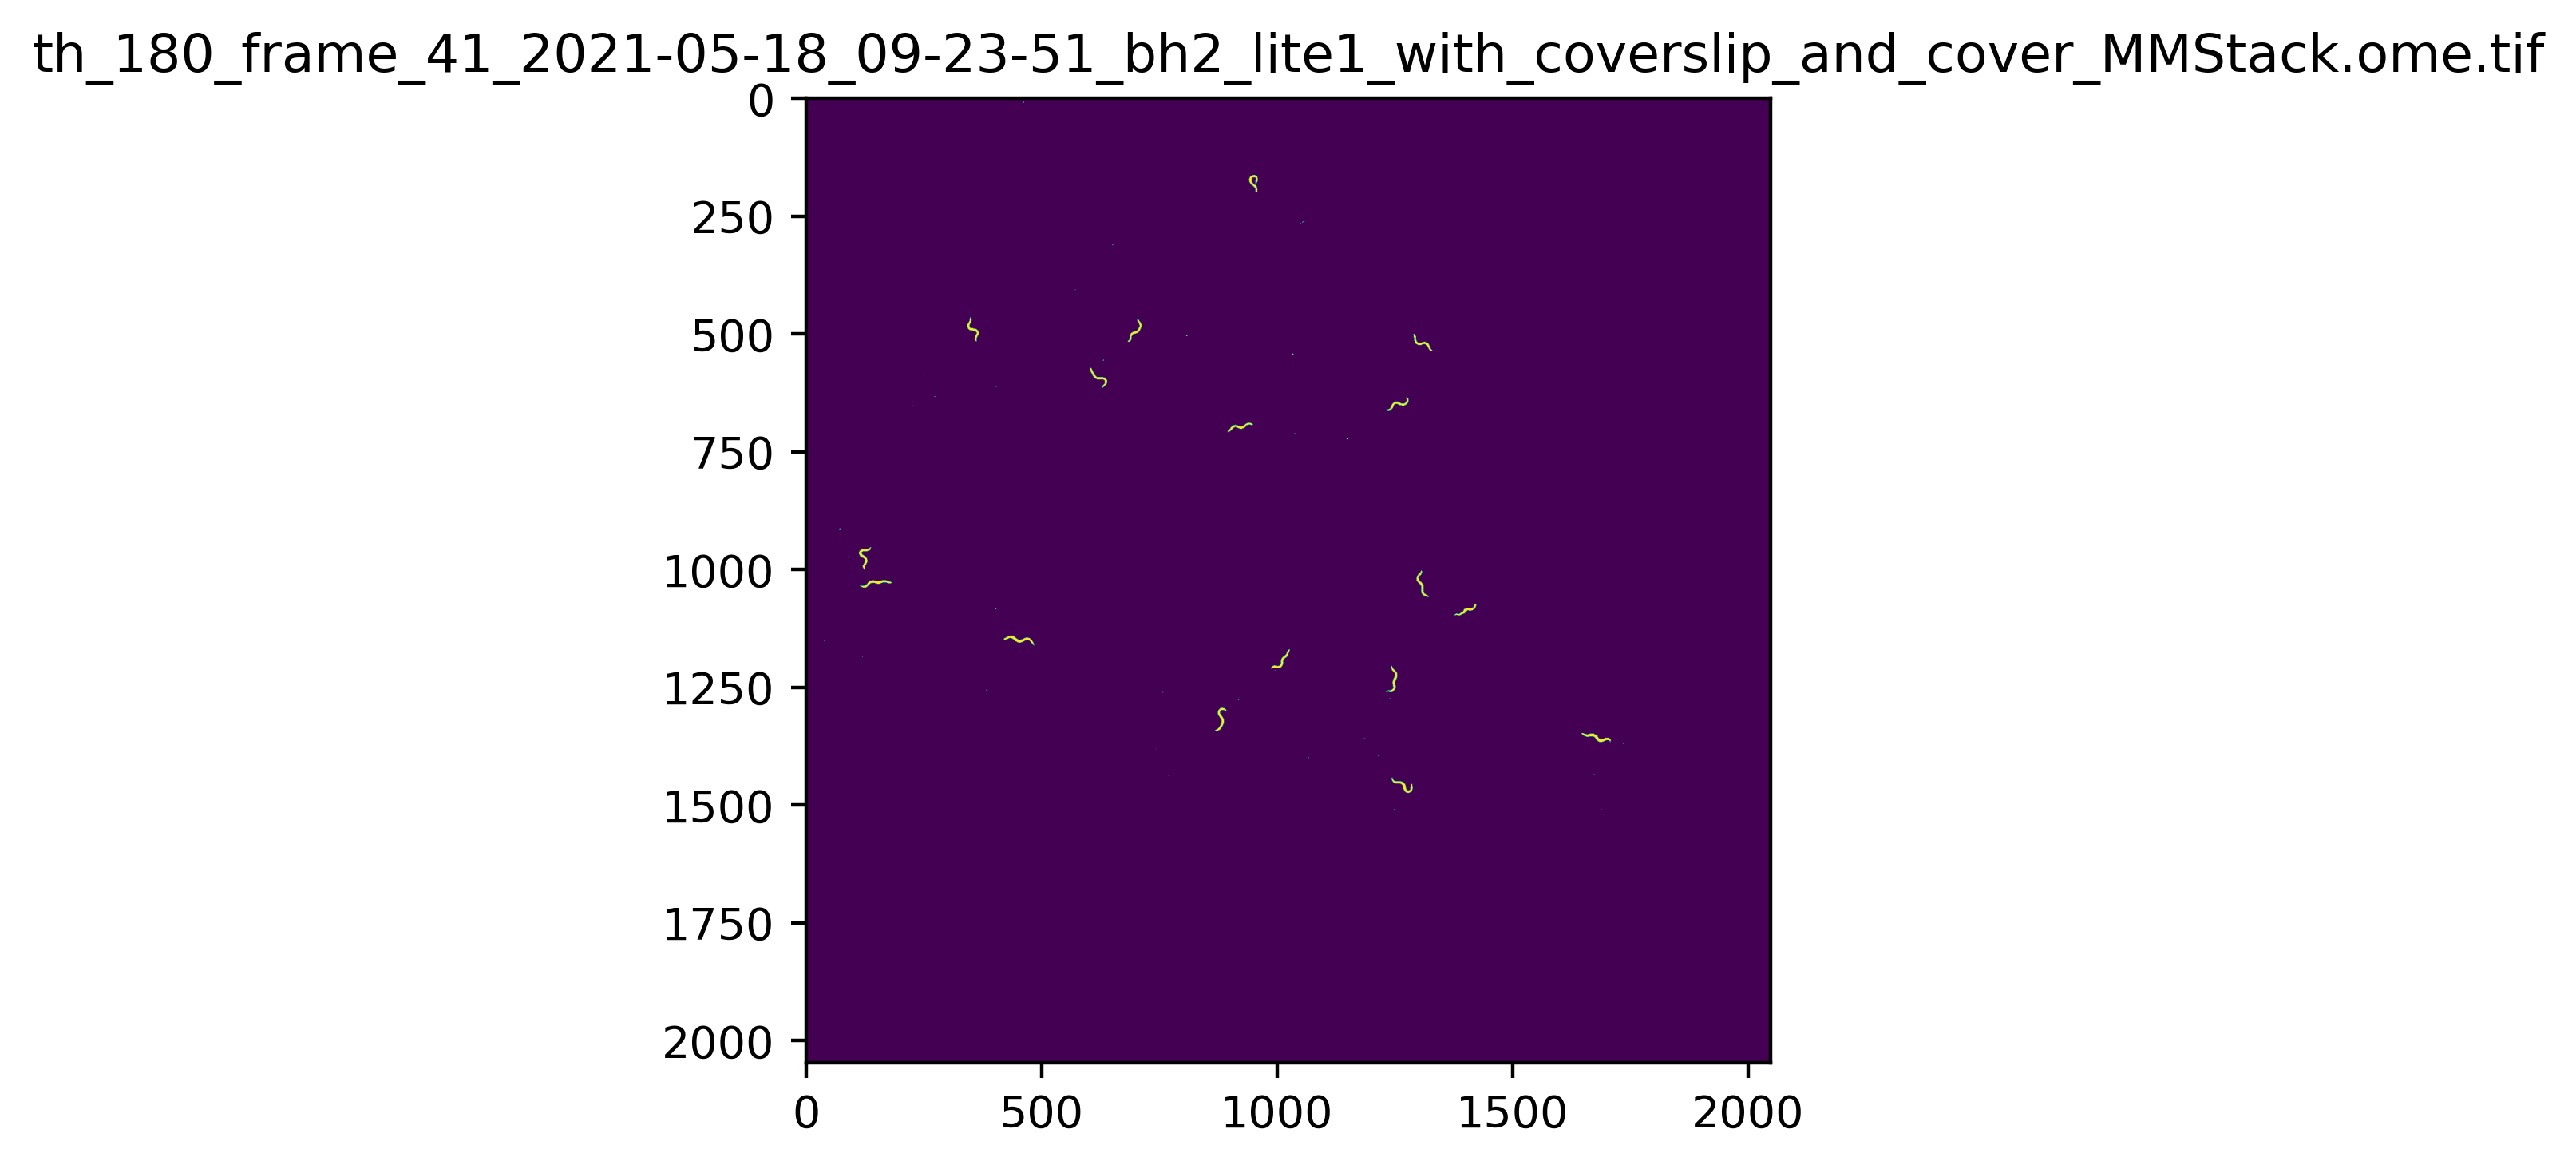

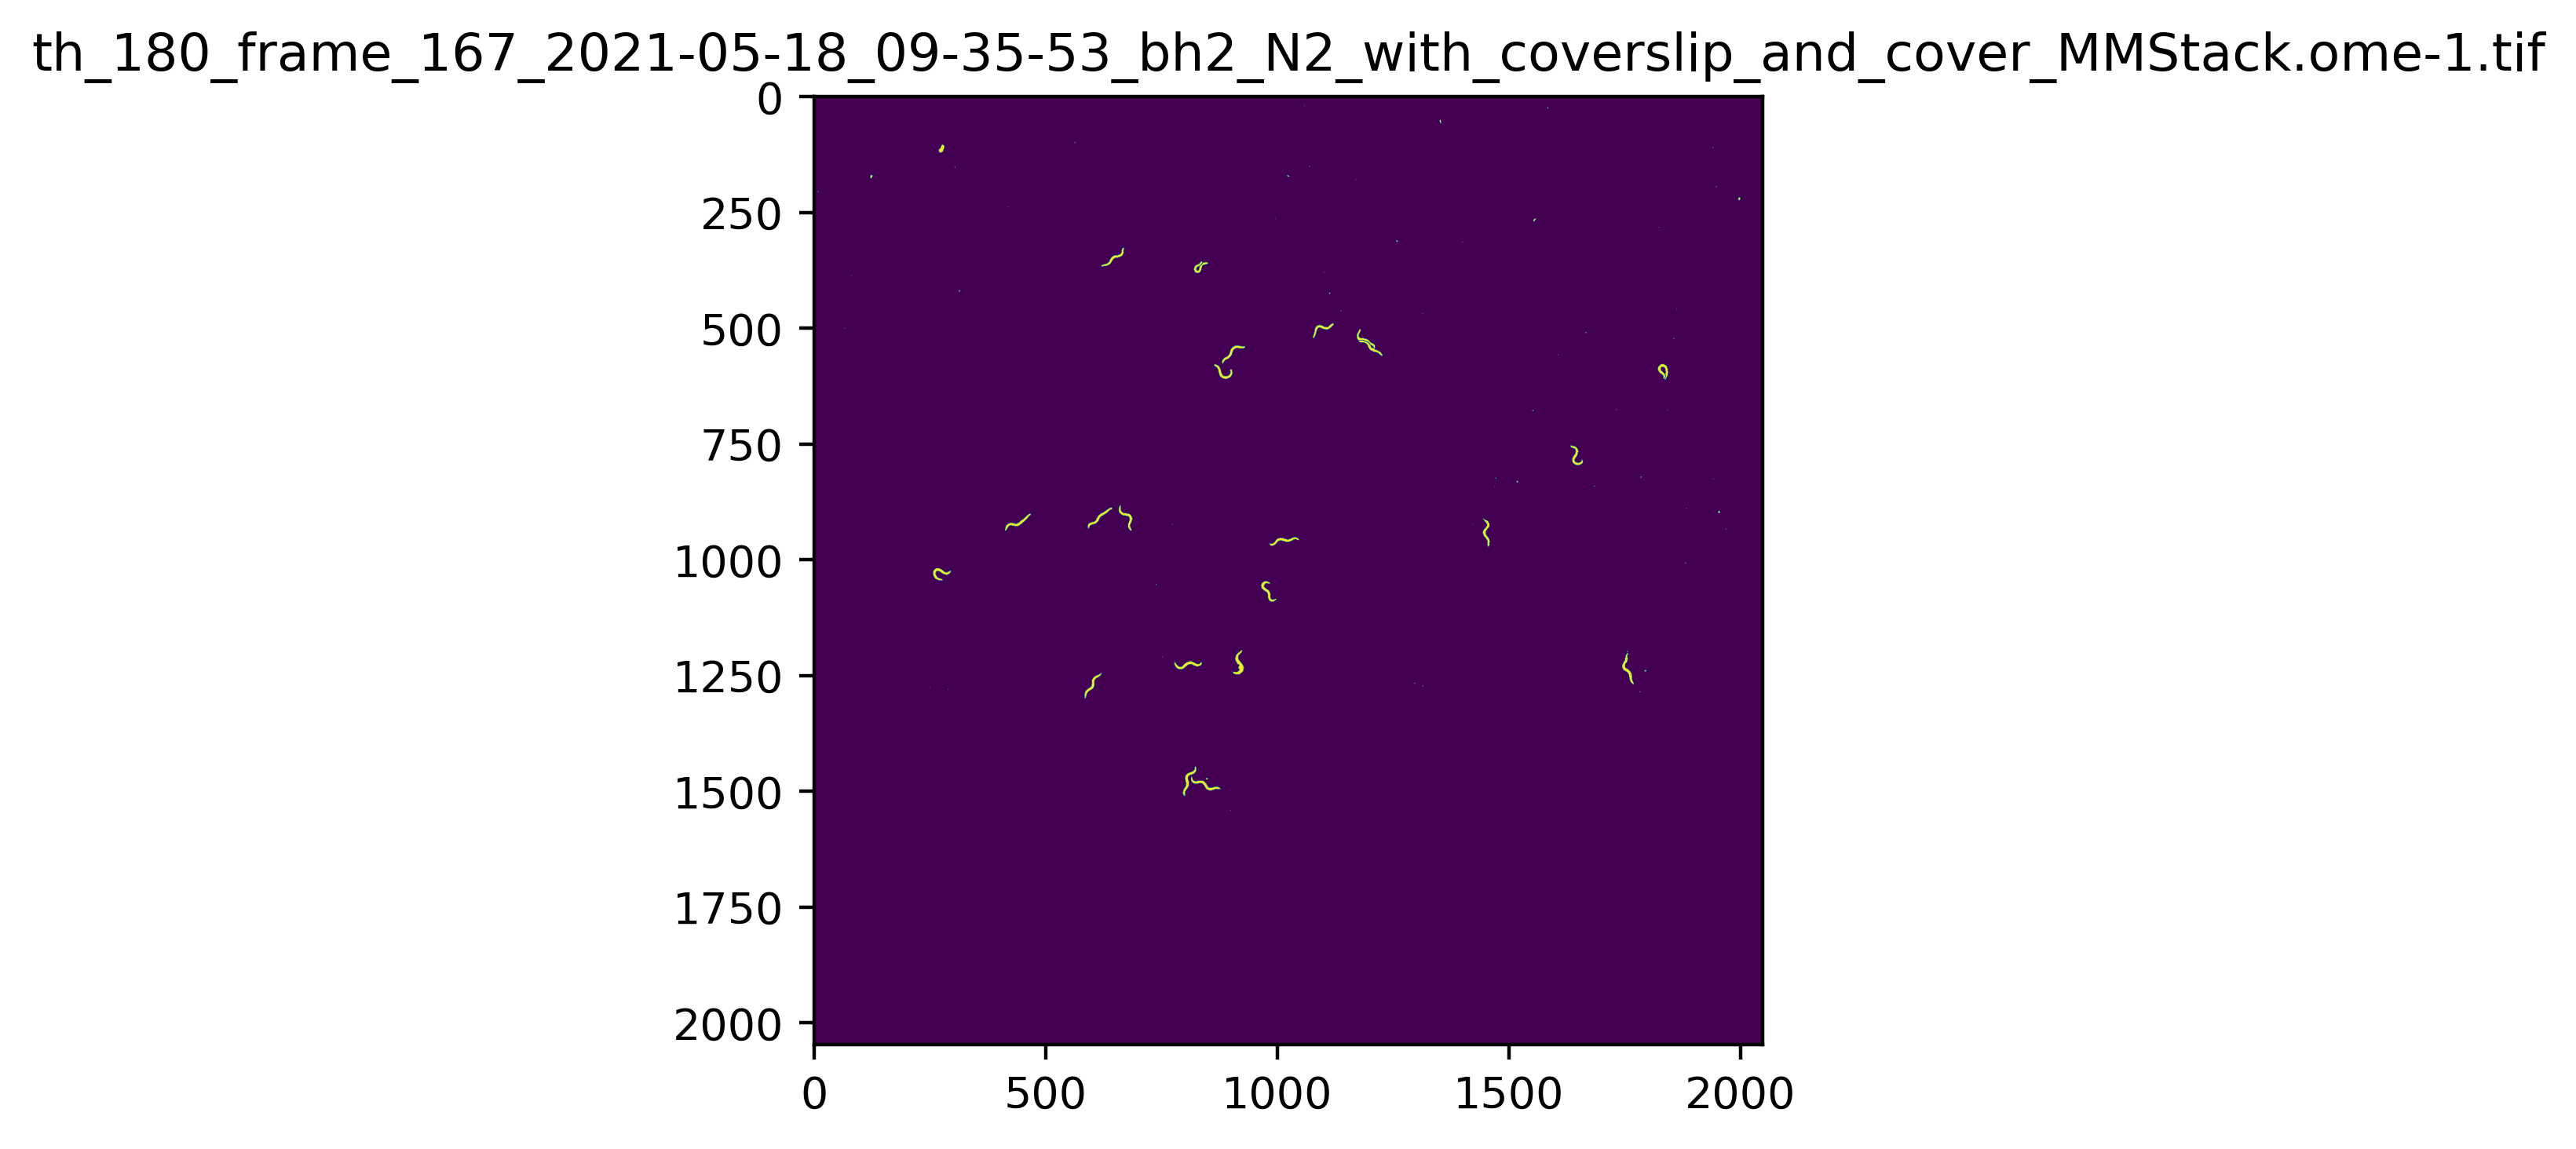

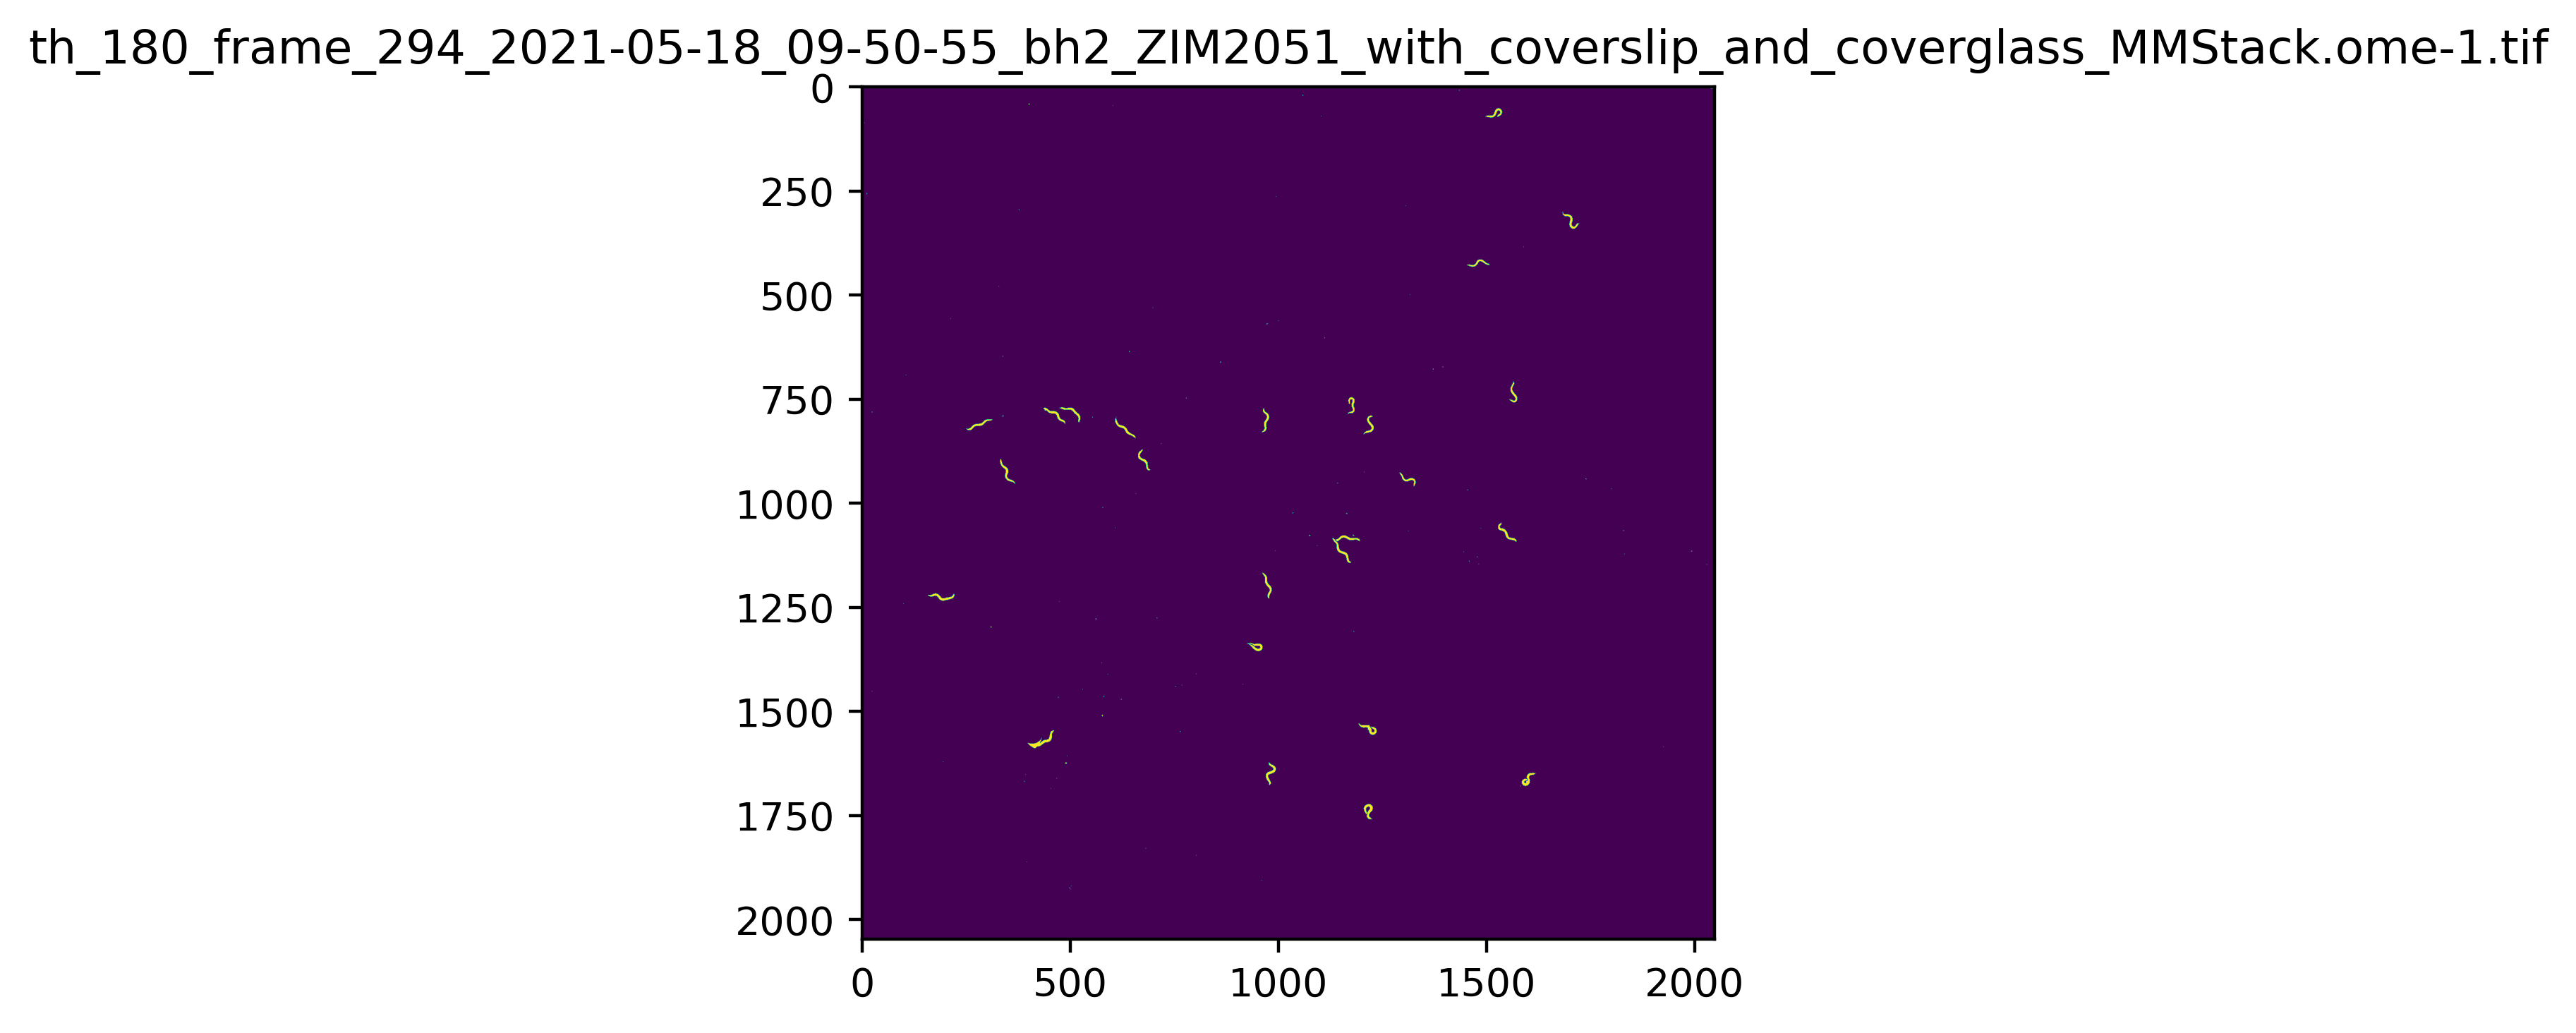

In [24]:
main_path='/scratch/zimmer/Ulises_temp/ZIM2051_Length_Experiment/processed_mask/with_coverslip_and_coverglass/'
for img_path in os.listdir(main_path):
    img=tiff.imread(os.path.join(main_path,img_path))
    plt.figure(dpi=400)
    plt.imshow(img)
    plt.title(img_path)
    plt.show()